## Ejercicio Time Series Forecast
Para este ejercicio vamos a predecir cuál será la demanda de pasajeros de una aerolinea, para poder anticiparse a las contrataciones de personal, mantenimiento de las aeronaves y gestión de inventario y comidas.

Para ello, se pide:
1. Carga datos (AirPassengers.csv) y representa la serie. ¿Hay seasonality? ¿Cada cuanto?
2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior. Tienes que usar la función rolling() del DataFrame.
3. Comprueba de manera estadística si la serie es o no stationary.
4. Aplica una transformación logarítmica sobre los datos para mejorar el proceso de transformación de tu time series a stationary. Acuérdate después del forecast de invertir la transformación.
5. Divide en train y test. Guarda 20 muestras para test.
6. Crea tu primer modelo ARIMA. Habrá varias combinaciones en función de sus hiperparámetros... Mide el MAE y RMSE del modelo en predicción. Ten en cuenta el parámetro "m" de la función ARIMA, mediante el cual se establece el seasonality.
7. Representa en una gráfica los datos de test y tus predicciones.
8. Prueba un decission tree y un random forest, a ver qué performance presentan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## 1. Carga datos y representa la serie

In [2]:
df = pd.read_csv("./data/AirPassengers.csv", parse_dates=["date"], index_col=["date"])

In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   value   144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [4]:
df.head(20)

,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


In [5]:
# df = pd.read_csv("./data/AirPassengers.csv", parse_dates=["date"], index_col="date")

def plot_df(df, x, y, title="", xlabel='Date', ylabel='Value', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.xticks(x[::12], rotation=45)
    plt.show()

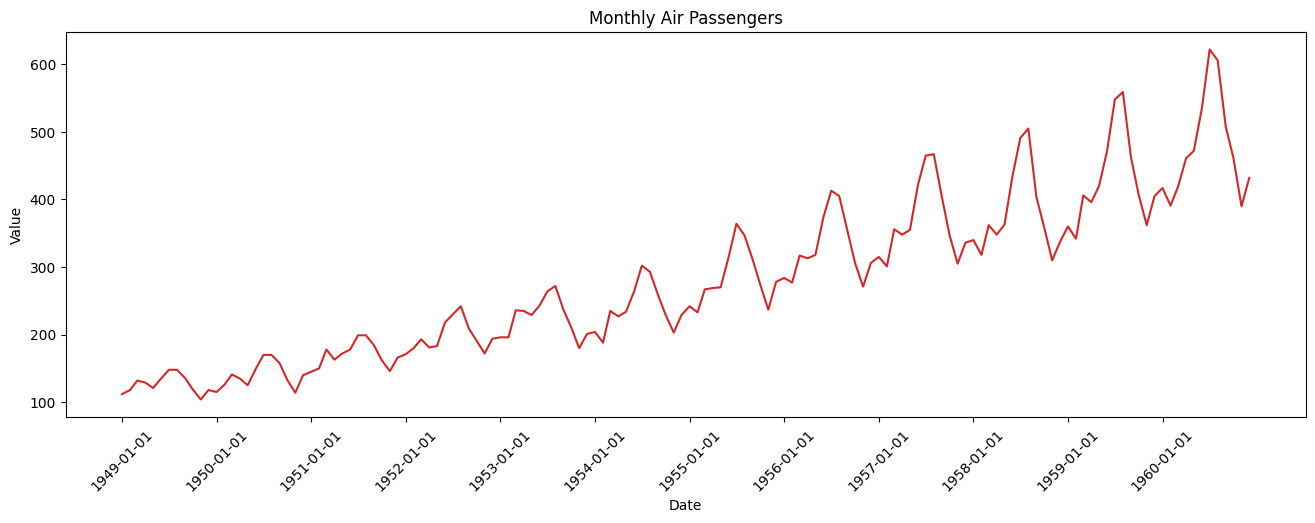

In [6]:
plot_df(df, x=df.index, y=df["value"], title="Monthly Air Passengers")

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

In [8]:
result_mul = seasonal_decompose(df["value"], model = "multiplicative", extrapolate_trend = "freq")

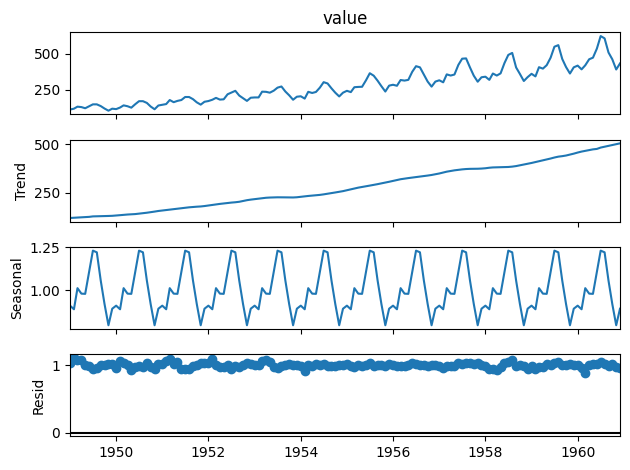

In [9]:
result_mul.plot();

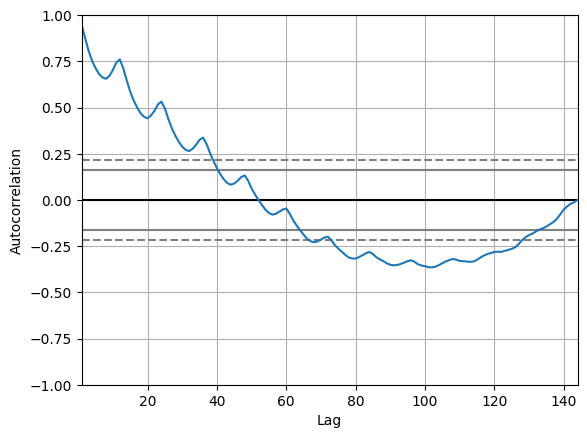

In [10]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(df["value"]);

## 2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior

In [11]:
def plot_df(df, y, title="", xlabel='Date', ylabel='Value', dpi=100):
    plt.figure(figsize=(6,5), dpi=dpi)
    
    rolling_mean = df[y].rolling(window=12).mean()
    
    plt.plot(df.index, df[y], color='tab:red', label='Original')
    plt.plot(df.index, rolling_mean, color='blue', label='Rolling Mean (12)', )
    
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.xticks(df.index[::12], rotation=45)
    plt.tight_layout()
    plt.show()

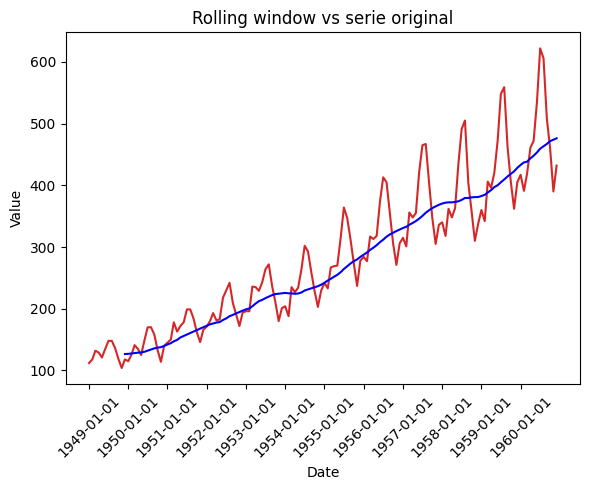

In [12]:
plot_df(df, y="value", title="Rolling window vs serie original")

## 3. Comprueba de manera estadística si la serie es o no stationary.

El test estadístico es positivo, lo cual implica que es mucho menos probable que rechacemos la hipótesis nula (no estacionaria).

Al comparar el estadístico ADF con los valores críticos, parece que no podríamos rechazar la hipótesis nula de que la serie temporal no es estacionaria y en consecuencia afirmamos que la serie tiene una estructura que sí que es dependiente del tiempo.

Un valor p por encima del umbral sugiere que no rechazamos la hipótesis nula (no estacionario).

In [13]:
from statsmodels.tsa.stattools import adfuller

In [14]:
print(f"ADF Statistic: {adfuller(df["value"])[0]}")
print(f"p-value: {adfuller(df["value"])[1]}")
print(f"Critical Values: \n {adfuller(df["value"])[4]}")

ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641
Critical Values: 
 {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}


## 4. Aplica una transformación logarítmica

Podemos ver que el valor es mayor que los valores críticos, lo que significa que podemos rechazar la hipótesis nula y, a su vez, que la serie de tiempo no es estacionaria.

Sin embargo nos sigue interesando aplicar la transformación porque conseguimos estabilizar la varianza.

In [15]:
df["value"] = np.log1p(df["value"])

In [16]:
print(f"ADF Statistic: {adfuller(df["value"])[0]}")
print(f"p-value: {adfuller(df["value"])[1]}")
print(f"Critical Values: \n {adfuller(df["value"])[4]}")

ADF Statistic: -1.7064106124214196
p-value: 0.42781260009224653
Critical Values: 
 {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}


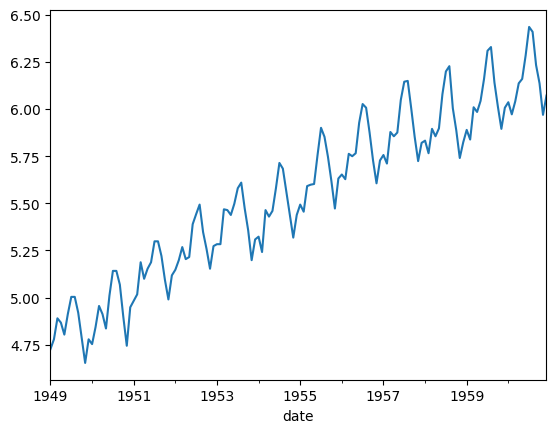

In [17]:
df["value"].plot();

## 5. Divide en train y test. Guarda 20 muestras para test.

In [18]:
df.reset_index(inplace=True)
df

,date,value
0,1949-01-01,4.727388
1,1949-02-01,4.779123
2,1949-03-01,4.890349
3,1949-04-01,4.867534
4,1949-05-01,4.804021
...,...,...
139,1960-08-01,6.408529
140,1960-09-01,6.232448
141,1960-10-01,6.135565
142,1960-11-01,5.968708


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
train = df["value"][0:124]
test = df["value"][124:]
print(train.shape)
print(test.shape)

(124,)
(20,)


In [21]:
train

0      4.727388
1      4.779123
2      4.890349
3      4.867534
4      4.804021
         ...   
119    5.823046
120    5.888878
121    5.837730
122    6.008813
123    5.983936
Name: value, Length: 124, dtype: float64

## 6. Crea tu primer modelo ARIMA

In [22]:
from pmdarima.arima import auto_arima
from pmdarima.arima import ARIMA

In [23]:
# import itertools
# p=d=q=range(0,5)
# pdq = list(itertools.product(p,d,q))
# pdq[:6]

In [24]:
# results = []
# for param in pdq:
#     try:
#         model_arima = ARIMA(order=param)
#         model_arima_fit = model_arima.fit(y_train)
#         results.append((param, model_arima_fit.aic()))
#     except:
#         continue

In [25]:
# resultados_df = pd.DataFrame(results, columns=["ARIMA params", "AIC"]).sort_values("AIC")
# resultados_df.head()

In [26]:
# best_model = ARIMA(order=(2, 3, 4))
# best_model.fit(y_train)

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [28]:
model = auto_arima(train,
                   start_p= 1,
                   start_q= 1,
                   max_p= 5,
                   max_q= 5,
                   max_d= 3,
                   trace=True,
                   warnings=False,
                   stationary=False,
                   error_action="ignore",
                   stepwise=True)

print(model.aic())
predictions = model.predict(20)

mse  = mean_squared_error(test.values, predictions)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(test.values, predictions)

print(f"MSE:  {mse}")
print(f"RMSE: {rmse}")
print(f"MAE:  {mae}")

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-210.169, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-202.479, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-203.994, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-205.400, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-203.310, Time=0.01 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.14 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.19 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.16 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-205.523, Time=0.07 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-226.929, Time=0.17 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-230.800, Time=0.21 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-227.851, Time=0.20 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=-234.976, Time=0.26 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=-215.964, Time=0.12 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=-233.9

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,1,1)[12] intercept   : AIC=-408.447, Time=0.67 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-294.133, Time=0.02 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-403.899, Time=0.45 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=-357.432, Time=0.33 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=-126.477, Time=0.02 sec
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=-415.946, Time=0.52 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=-388.347, Time=0.26 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=-414.037, Time=1.92 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=-409.560, Time=0.68 sec
 ARIMA(1,0,1)(1,1,2)[12] intercept   : AIC=-412.441, Time=2.74 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=-412.579, Time=0.34 sec
 ARIMA(2,0,1)(0,1,1)[12] intercept   : AIC=-415.211, Time=0.49 sec
 ARIMA(1,0,2)(0,1,1)[12] intercept   : AIC=-414.359, Time=0.87 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=-304.397, Time=0.13 sec
 ARIMA(0,0,2)(0,1,1

In [39]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  124
Model:               SARIMAX(0, 1, 1)   Log Likelihood                 -79.023
Date:               lu., 11 may. 2026   AIC                            162.047
Time:                        21:14:22   BIC                            167.671
Sample:                             0   HQIC                           164.332
                                - 124                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9718      0.033    -29.068      0.000      -1.037      -0.906
sigma2         0.2067      0.039      5.358      0.000       0.131       0.282
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 5.93
Prob(Q):                              0.87   Prob(JB):                         0.05
Heteroskedasticity (H):               0.85   Skew:                            -0.06
Prob(H) (two-sided):                  0.61   Kurtosis:                         1.93
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## 7. Representa en una gráfica los datos de test y tus predicciones.

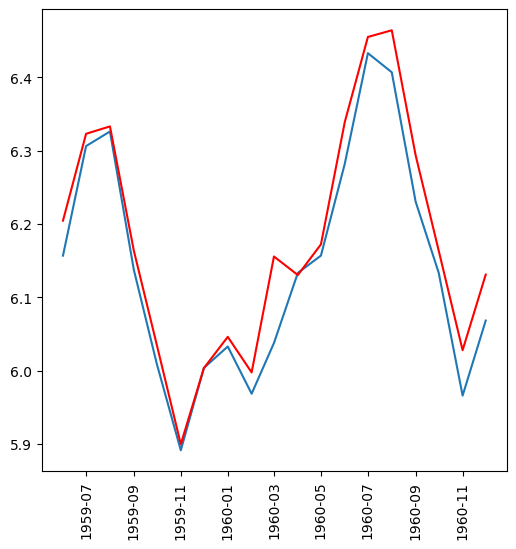

In [16]:
test

date
1959-06-01    6.156979
1959-07-01    6.306275
1959-08-01    6.326149
1959-09-01    6.137727
1959-10-01    6.008813
1959-11-01    5.891644
1959-12-01    6.003887
1960-01-01    6.033086
1960-02-01    5.968708
1960-03-01    6.037871
1960-04-01    6.133398
1960-05-01    6.156979
1960-06-01    6.282267
1960-07-01    6.432940
1960-08-01    6.406880
1960-09-01    6.230481
1960-10-01    6.133398
1960-11-01    5.966147
1960-12-01    6.068426
Name: value, dtype: float64

## 8. Prueba otros modelos, a ver qué performance presentan.

In [18]:
df.head()

,value,t-12,t-11,t-10,t-9,t-8,t-7,t-6,t-5,t-4,t-3,t-2,t-1
date,,,,,,,,,,,,,
1950-01-01,4.744932,4.718499,4.770685,4.882802,4.859812,4.795791,4.905275,4.997212,4.997212,4.912655,4.779123,4.644391,4.770685
1950-02-01,4.836282,4.770685,4.882802,4.859812,4.795791,4.905275,4.997212,4.997212,4.912655,4.779123,4.644391,4.770685,4.744932
1950-03-01,4.948760,4.882802,4.859812,4.795791,4.905275,4.997212,4.997212,4.912655,4.779123,4.644391,4.770685,4.744932,4.836282
1950-04-01,4.905275,4.859812,4.795791,4.905275,4.997212,4.997212,4.912655,4.779123,4.644391,4.770685,4.744932,4.836282,4.948760
1950-05-01,4.828314,4.795791,4.905275,4.997212,4.997212,4.912655,4.779123,4.644391,4.770685,4.744932,4.836282,4.948760,4.905275


Shape X_train: (113, 12)
Shape X_test: (19, 12)
Shape y_train: (113,)
Shape y_test: (19,)


MSE: 0.003950286274393626
RMSE: 0.06285130288541062
MAE: 0.035043466162095575


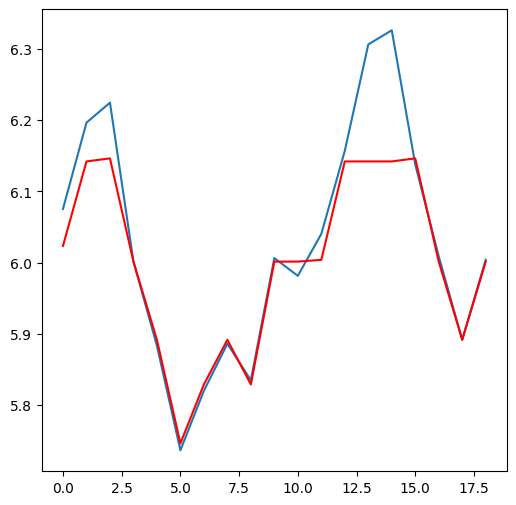